# Notebook 02: Main OLS Regressions & Coefficient Plots

**Replication of:** Appel, Pan & Roberts (2023), Figures 1-3.

This notebook runs the core OLS regressions with interactions, survey weights, and clustered standard errors, then produces coefficient plots replicating the main figures.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    load_main_data, fit_ols_clustered, tidy,
    plot_coefficients, OUTCOME_LABELS, COEF_LABELS
)

pd.set_option('display.max_columns', 20)
%matplotlib inline

In [2]:
df = load_main_data()
print(f'Loaded {df.shape[0]} observations, {df["id"].nunique()} respondents')

Loaded 2240 observations, 1120 respondents


## 1. Main Regression Specification

The core model is:

$$\text{outcome}_i = \beta_{D} \cdot D_i + \beta_{R} \cdot R_i + \gamma_{D} \cdot (D_i \times \text{ProDem}_i) + \gamma_{R} \cdot (R_i \times \text{ProRep}_i) + \varepsilon_i$$

- No intercept (`~ 0 + ...`) so $\beta_D$ and $\beta_R$ give baseline levels for each party
- $\gamma_D$ captures Democrats' **party promotion** (difference when headline is pro-Democrat vs. pro-Republican)
- $\gamma_R$ captures Republicans' party promotion
- Weighted by survey weights, SEs clustered on respondent `id`

In [3]:
MAIN_FORMULA = '{outcome} ~ 0 + C(party_id) + party_id_dem:headline_pro_dem + party_id_rep:headline_pro_rep'

## 2. All Respondents (Figure 3 Regressions)

In [4]:
results_all = {}
for outcome in ['remove', 'harm', 'censorship']:
    formula = MAIN_FORMULA.format(outcome=outcome)
    res = fit_ols_clustered(formula, df, cluster_var='id', weight_var='weight')
    results_all[outcome] = res
    
    print(f'\n=== {OUTCOME_LABELS[outcome]} (All Respondents) ===')
    print(f'N = {int(res.nobs)}, R² = {res.rsquared:.4f}')
    display(tidy(res).round(4))


=== Intent to Remove Headline (All Respondents) ===
N = 2190, R² = 0.1284


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.7455,0.0205,0.0000,0.7052,0.7858
1,C(party_id)[Republican],0.3400,0.0256,0.0000,0.2898,0.3902
2,party_id_dem:headline_pro_dem,-0.1100,0.0228,0.0000,-0.1546,-0.0654
3,party_id_rep:headline_pro_rep,0.0020,0.0227,0.9296,-0.0424,0.0464



=== Intent to Report Headline as Harmful (All Respondents) ===
N = 2192, R² = 0.0620


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.5586,0.0233,0.0000,0.5129,0.6042
1,C(party_id)[Republican],0.2545,0.0230,0.0000,0.2094,0.2997
2,party_id_dem:headline_pro_dem,-0.1301,0.0267,0.0000,-0.1824,-0.0779
3,party_id_rep:headline_pro_rep,0.0328,0.0272,0.2271,-0.0204,0.0861



=== Perception of Headline Removal as Censorship (All Respondents) ===
N = 1774, R² = 0.1291


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.2809,0.0242,0.0000,0.2335,0.3284
1,C(party_id)[Republican],0.6462,0.0283,0.0000,0.5908,0.7017
2,party_id_dem:headline_pro_dem,0.0125,0.0199,0.5304,-0.0265,0.0515
3,party_id_rep:headline_pro_rep,-0.0015,0.0265,0.9564,-0.0535,0.0506


## 3. Inaccurate Subgroup (Figure 1 Regressions)

Restrict to headlines rated as inaccurate by the respondent (`accuracy_binary == 0`). This tests whether partisan differences persist even when respondents agree a headline is false.

In [5]:
results_inacc = {}
for outcome in ['remove', 'harm', 'censorship']:
    formula = MAIN_FORMULA.format(outcome=outcome)
    res = fit_ols_clustered(formula, df, cluster_var='id', weight_var='weight',
                            subset='accuracy_binary == 0')
    results_inacc[outcome] = res
    
    print(f'\n=== {OUTCOME_LABELS[outcome]} (Inaccurate Subgroup) ===')
    print(f'N = {int(res.nobs)}, R² = {res.rsquared:.4f}')
    display(tidy(res).round(4))


=== Intent to Remove Headline (Inaccurate Subgroup) ===
N = 1721, R² = 0.1238


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.7892,0.0207,0.0000,0.7486,0.8298
1,C(party_id)[Republican],0.4023,0.0302,0.0000,0.3431,0.4614
2,party_id_dem:headline_pro_dem,-0.0711,0.0210,0.0007,-0.1122,-0.0300
3,party_id_rep:headline_pro_rep,0.0281,0.0297,0.3435,-0.0301,0.0864



=== Intent to Report Headline as Harmful (Inaccurate Subgroup) ===
N = 1720, R² = 0.0548


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.5743,0.0248,0.0000,0.5257,0.6230
1,C(party_id)[Republican],0.2983,0.0276,0.0000,0.2442,0.3523
2,party_id_dem:headline_pro_dem,-0.1078,0.0297,0.0003,-0.1660,-0.0495
3,party_id_rep:headline_pro_rep,0.0189,0.0323,0.5587,-0.0444,0.0822



=== Perception of Headline Removal as Censorship (Inaccurate Subgroup) ===
N = 1407, R² = 0.1135


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.2526,0.0250,0.0000,0.2036,0.3016
1,C(party_id)[Republican],0.6046,0.0329,0.0000,0.5401,0.6691
2,party_id_dem:headline_pro_dem,0.0076,0.0214,0.7221,-0.0343,0.0496
3,party_id_rep:headline_pro_rep,-0.0360,0.0346,0.2982,-0.1040,0.0319


## 4. Accuracy Model (Figure 2)

Model predicting accuracy ratings to show that partisans differentially rate aligned headlines as more accurate.

In [6]:
acc_formula = 'accuracy_binary ~ 0 + C(party_id) + party_id_dem:headline_pro_dem + party_id_rep:headline_pro_rep'
res_acc = fit_ols_clustered(acc_formula, df, cluster_var='id', weight_var='weight')

print('=== Accuracy Binary (All Respondents) ===')
print(f'N = {int(res_acc.nobs)}, R² = {res_acc.rsquared:.4f}')
display(tidy(res_acc).round(4))

=== Accuracy Binary (All Respondents) ===
N = 2170, R² = 0.0337


,term,estimate,std_error,p_value,conf_low,conf_high
0,C(party_id)[Democrat],0.1085,0.0142,0.0000,0.0807,0.1363
1,C(party_id)[Republican],0.2117,0.0224,0.0000,0.1678,0.2556
2,party_id_dem:headline_pro_dem,0.1406,0.0219,0.0000,0.0978,0.1835
3,party_id_rep:headline_pro_rep,0.1072,0.0297,0.0003,0.0491,0.1653


## 5. Coefficient Plots

### Figure 1: Inaccurate Subgroup

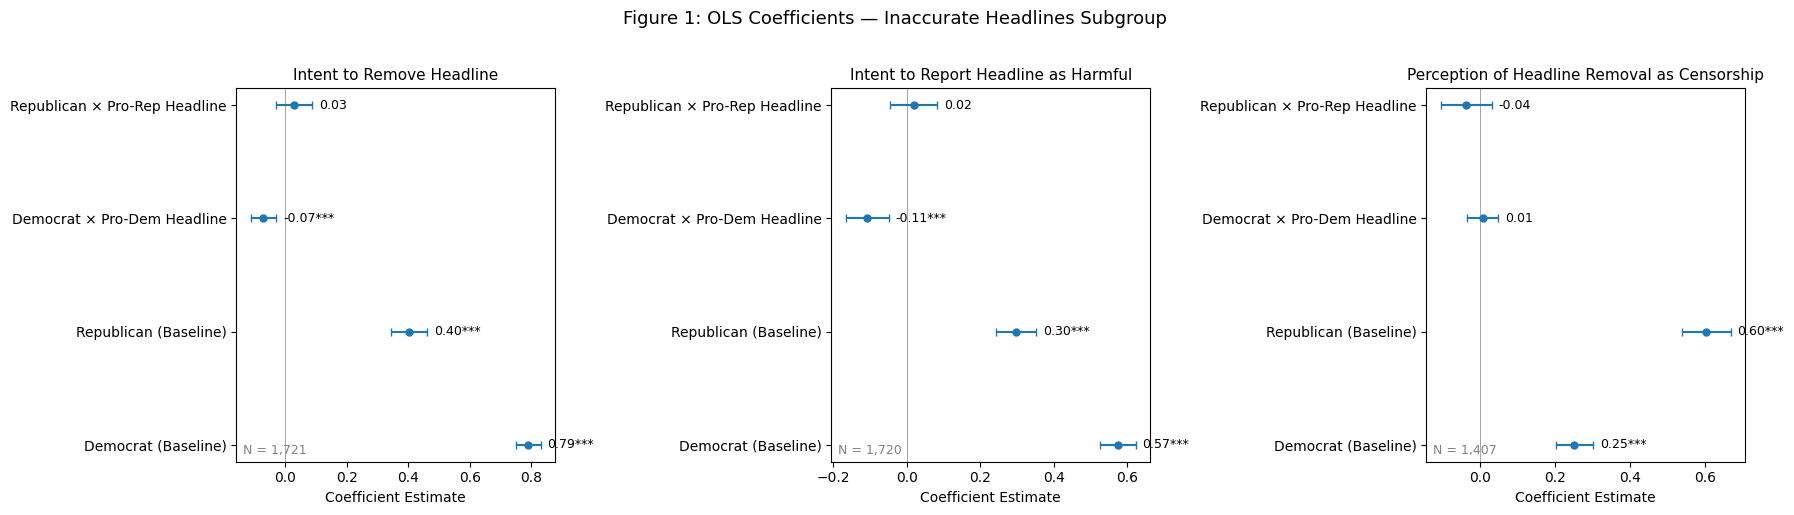

In [7]:
coef_vars = {
    'C(party_id)[Democrat]': 'Democrat (Baseline)',
    'C(party_id)[Republican]': 'Republican (Baseline)',
    'party_id_dem:headline_pro_dem': 'Democrat × Pro-Dem Headline',
    'party_id_rep:headline_pro_rep': 'Republican × Pro-Rep Headline',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, outcome in zip(axes, ['remove', 'harm', 'censorship']):
    res = results_inacc[outcome]
    td = tidy(res)
    td = td[td['term'].isin(coef_vars.keys())].copy()
    td['label'] = td['term'].map(coef_vars)
    
    colors = ['#1f77b4'] * len(td)
    y_pos = range(len(td))
    
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.errorbar(td['estimate'], td['label'], 
                xerr=[td['estimate'] - td['conf_low'], td['conf_high'] - td['estimate']],
                fmt='o', color='#1f77b4', capsize=3, markersize=5)
    
    for _, row in td.iterrows():
        stars = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else ''
        ax.annotate(f"{row['estimate']:.2f}{stars}", 
                    (row['conf_high'], row['label']),
                    xytext=(5, 0), textcoords='offset points', fontsize=9, va='center')
    
    ax.set_title(OUTCOME_LABELS[outcome], fontsize=11)
    ax.set_xlabel('Coefficient Estimate')
    ax.annotate(f'N = {int(res.nobs):,}', xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=9, color='grey')

fig.suptitle('Figure 1: OLS Coefficients — Inaccurate Headlines Subgroup', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Figure 2: Accuracy Model

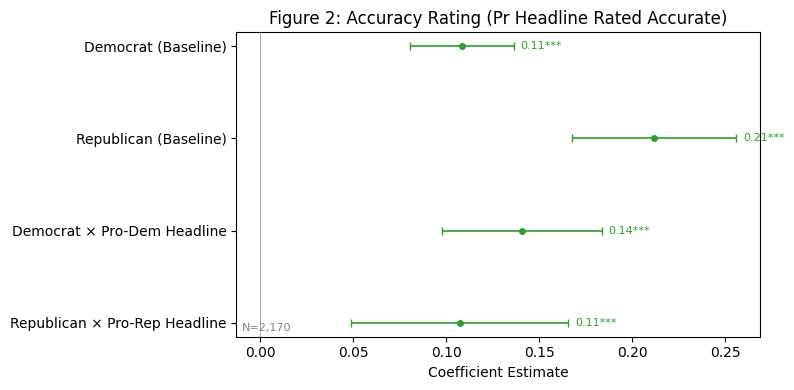

In [8]:
fig2, ax2 = plot_coefficients(
    {'Accuracy': res_acc},
    variables=coef_vars,
    title='Figure 2: Accuracy Rating (Pr Headline Rated Accurate)',
    colors=['#2ca02c'],
    figsize=(8, 4)
)
plt.show()

### Figure 3: All Respondents

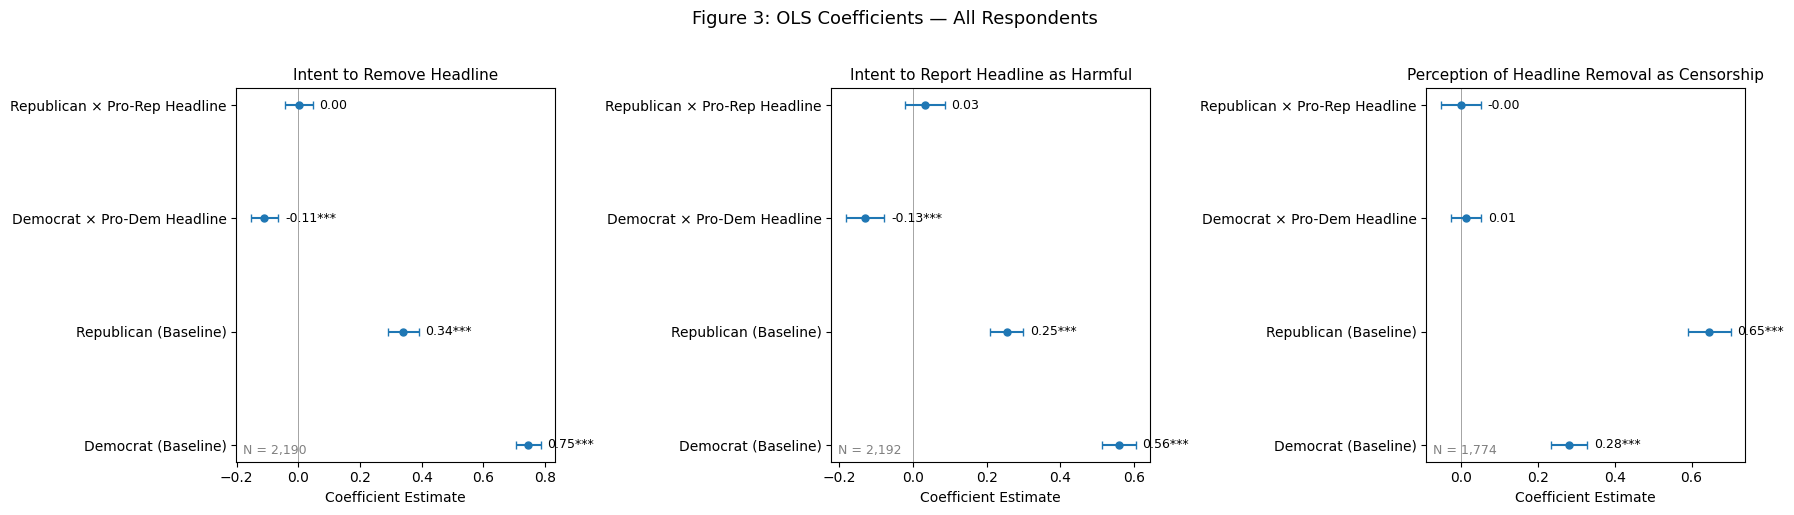

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, outcome in zip(axes, ['remove', 'harm', 'censorship']):
    res = results_all[outcome]
    td = tidy(res)
    td = td[td['term'].isin(coef_vars.keys())].copy()
    td['label'] = td['term'].map(coef_vars)
    
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.errorbar(td['estimate'], td['label'],
                xerr=[td['estimate'] - td['conf_low'], td['conf_high'] - td['estimate']],
                fmt='o', color='#1f77b4', capsize=3, markersize=5)
    
    for _, row in td.iterrows():
        stars = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else ''
        ax.annotate(f"{row['estimate']:.2f}{stars}", 
                    (row['conf_high'], row['label']),
                    xytext=(5, 0), textcoords='offset points', fontsize=9, va='center')
    
    ax.set_title(OUTCOME_LABELS[outcome], fontsize=11)
    ax.set_xlabel('Coefficient Estimate')
    ax.annotate(f'N = {int(res.nobs):,}', xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=9, color='grey')

fig.suptitle('Figure 3: OLS Coefficients — All Respondents', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 6. Verification Table

Compare Python coefficients against published values from the paper.

In [10]:
# Published key results from the paper (all respondents)
# These are approximate baseline values from the descriptive statistics
# Paper targets: Pr(Remove): D=0.69, R=0.34; Pr(Harm): D=0.49, R=0.27; Pr(Censor): D=0.29, R=0.65

verification = []
for outcome in ['remove', 'harm', 'censorship']:
    res = results_all[outcome]
    td = tidy(res)
    for _, row in td.iterrows():
        verification.append({
            'Outcome': outcome,
            'Subgroup': 'All',
            'Term': row['term'],
            'Coef (Python)': round(row['estimate'], 4),
            'SE (Python)': round(row['std_error'], 4),
            'p-value': round(row['p_value'], 4),
        })

for outcome in ['remove', 'harm', 'censorship']:
    res = results_inacc[outcome]
    td = tidy(res)
    for _, row in td.iterrows():
        verification.append({
            'Outcome': outcome,
            'Subgroup': 'Inaccurate',
            'Term': row['term'],
            'Coef (Python)': round(row['estimate'], 4),
            'SE (Python)': round(row['std_error'], 4),
            'p-value': round(row['p_value'], 4),
        })

verify_df = pd.DataFrame(verification)
display(verify_df)

,Outcome,Subgroup,Term,Coef (Python),SE (Python),p-value
0,remove,All,C(party_id)[Democrat],0.7455,0.0205,0.0000
1,remove,All,C(party_id)[Republican],0.3400,0.0256,0.0000
2,remove,All,party_id_dem:headline_pro_dem,-0.1100,0.0228,0.0000
3,remove,All,party_id_rep:headline_pro_rep,0.0020,0.0227,0.9296
4,harm,All,C(party_id)[Democrat],0.5586,0.0233,0.0000
5,harm,All,C(party_id)[Republican],0.2545,0.0230,0.0000
6,harm,All,party_id_dem:headline_pro_dem,-0.1301,0.0267,0.0000
7,harm,All,party_id_rep:headline_pro_rep,0.0328,0.0272,0.2271
8,censorship,All,C(party_id)[Democrat],0.2809,0.0242,0.0000
9,censorship,All,C(party_id)[Republican],0.6462,0.0283,0.0000


In [11]:
# Quick comparison: baseline party coefficients vs. paper's descriptive means
print('Baseline comparison (all respondents):')
print(f"  Remove — Democrat: {results_all['remove'].params['C(party_id)[Democrat]']:.2f} (paper: ~0.69)")
print(f"  Remove — Republican: {results_all['remove'].params['C(party_id)[Republican]']:.2f} (paper: ~0.34)")
print(f"  Harm — Democrat: {results_all['harm'].params['C(party_id)[Democrat]']:.2f} (paper: ~0.49)")
print(f"  Harm — Republican: {results_all['harm'].params['C(party_id)[Republican]']:.2f} (paper: ~0.27)")
print(f"  Censorship — Democrat: {results_all['censorship'].params['C(party_id)[Democrat]']:.2f} (paper: ~0.29)")
print(f"  Censorship — Republican: {results_all['censorship'].params['C(party_id)[Republican]']:.2f} (paper: ~0.65)")
print()
print('Note: Baseline coefficients represent predicted values when headline_pro_dem=0 and headline_pro_rep=0')
print('(i.e., for a misaligned headline). They may differ slightly from overall descriptive means.')
print('SE differences of 1-3% expected due to CR1 (Python) vs CR2 (R) clustering.')

Baseline comparison (all respondents):
  Remove — Democrat: 0.75 (paper: ~0.69)
  Remove — Republican: 0.34 (paper: ~0.34)
  Harm — Democrat: 0.56 (paper: ~0.49)
  Harm — Republican: 0.25 (paper: ~0.27)
  Censorship — Democrat: 0.28 (paper: ~0.29)
  Censorship — Republican: 0.65 (paper: ~0.65)

Note: Baseline coefficients represent predicted values when headline_pro_dem=0 and headline_pro_rep=0
(i.e., for a misaligned headline). They may differ slightly from overall descriptive means.
SE differences of 1-3% expected due to CR1 (Python) vs CR2 (R) clustering.


## Summary

Key regression findings:
1. **Large partisan baseline gap**: Democrats are ~35pp more likely to support removal, ~22pp more likely to report harm; Republicans are ~36pp more likely to call it censorship
2. **Party promotion**: Democrats show significant negative coefficient on pro-Dem headline interaction (they're less willing to remove co-party headlines). Republican party promotion is small and often insignificant.
3. **Persists among inaccurate headlines**: Even when respondents agree a headline is false, partisan gaps in moderation preferences remain large
4. **Accuracy perceptions are partisan**: Both parties rate co-partisan headlines as more accurate (significant positive interaction terms)